# CatHCAV - voting dataset

In [1]:
# disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## voting dataset

In [2]:
# poison dataset
from clustvartools.datasets import voting
data = voting.data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   affiliation  435 non-null    str  
 1   budget       435 non-null    str  
 2   physician    435 non-null    str  
 3   salvador     435 non-null    str  
 4   nicaraguan   435 non-null    str  
 5   missile      435 non-null    str  
 6   education    435 non-null    str  
dtypes: str(7)
memory usage: 23.9 KB


## Instanciation and training

In [3]:
# instanciation
from clustvartools import CatHCAV
clf = CatHCAV(ncl=2,sup_var=0)

### `fit` function

In [4]:
# fit function
clf.fit(data)

,sup_var,0
,ncl,2
,method,'cramer'
,metric,<function Cat...001AE764A0AE0>
,linkage,'ward'
,normalize,True
Name,Type,Value
call_,call,call(Xtot= ...affiliation'])
quali_var_,quali_var,quali_var(clu... 0.621297)
quali_var_sup_,quali_var_sup,quali_var_sup... 0.659078)


### `fit_transform` function

In [5]:
# fit_transform function - ward distance to cluster
dist = clf.fit_transform(data)
dist

,1,2
budget,0.384252,0.221354
physician,0.358645,0.212976
salvador,0.207755,0.361768
nicaraguan,0.210917,0.374001
missile,0.224231,0.415852
education,0.408724,0.253939


### `transform` function

In [6]:
# transform function - ward distance to cluster
dist = clf.transform(data)
dist

,1,2
affiliation,0.249775,0.164621
budget,0.384252,0.221354
physician,0.358645,0.212976
salvador,0.207755,0.361768
nicaraguan,0.210917,0.374001
missile,0.224231,0.415852
education,0.408724,0.253939


### `fit_predict` function

In [7]:
# fit_predict function
prediction = clf.fit_predict(data)
prediction.to_frame()

,cluster
budget,2
physician,2
salvador,1
nicaraguan,1
missile,1
education,2


### `predict` function

In [8]:
# predict function
prediction = clf.predict(data)
prediction.to_frame()

,cluster
affiliation,2
budget,2
physician,2
salvador,1
nicaraguan,1
missile,1
education,2


In [9]:
# attributes
from clustvartools import sprintf
sprintf(clf)


**Clustering of Variables - CatHCAV**

*The results are available in the following objects:

name             description
---------------  ---------------------------------------------------
.call_           summary called parameters
.quali_var_      results for the categorical variables
.quali_var_sup_  results for the supplementary categorical variables



## Variables informations

In [10]:
# variables informations
var_ = clf.quali_var_
var_._fields

('cluster', 'dist', 'member')

### Cluster distance

In [11]:
# cluster distance
var_.dist

,1,2
budget,0.384252,0.221354
physician,0.358645,0.212976
salvador,0.207755,0.361768
nicaraguan,0.210917,0.374001
missile,0.224231,0.415852
education,0.408724,0.253939


### Cluster member

In [12]:
# cluster member
var_.member.sort_values(by=["Cluster","Variable"])

,Variable,Cluster,Own Cluster,Next Closest,Ratio (Own/Next)
4,missile,1,0.224231,0.415852,0.539209
3,nicaraguan,1,0.210917,0.374001,0.563948
2,salvador,1,0.207755,0.361768,0.574277
0,budget,2,0.221354,0.384252,0.576064
5,education,2,0.253939,0.408724,0.621297
1,physician,2,0.212976,0.358645,0.593836


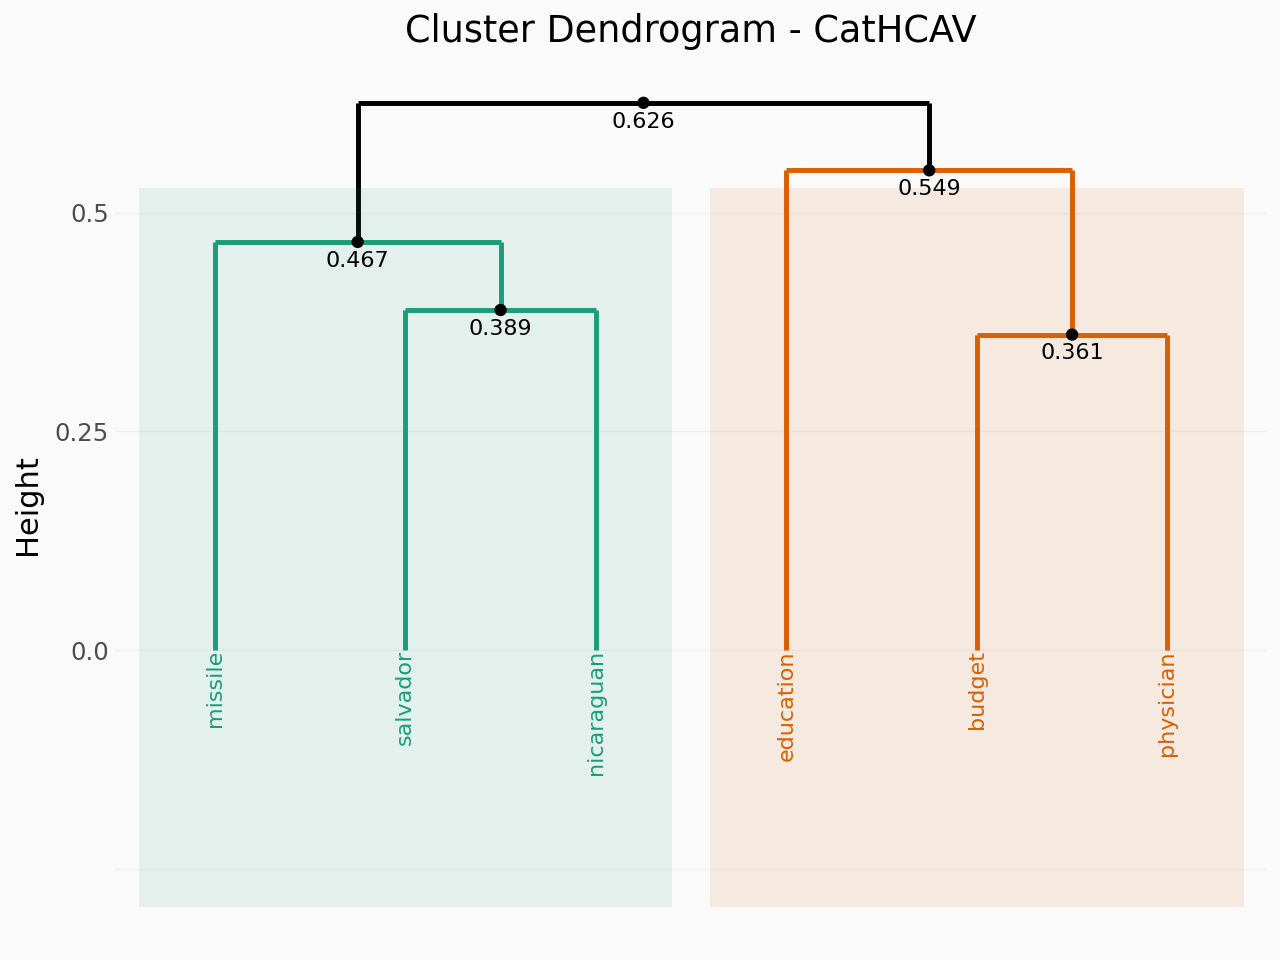

None


In [13]:
# dendrogram
from clustvartools import fviz_dend, fviz_height
p = fviz_dend(obj=clf,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_y=-0.01)
print(p.show())

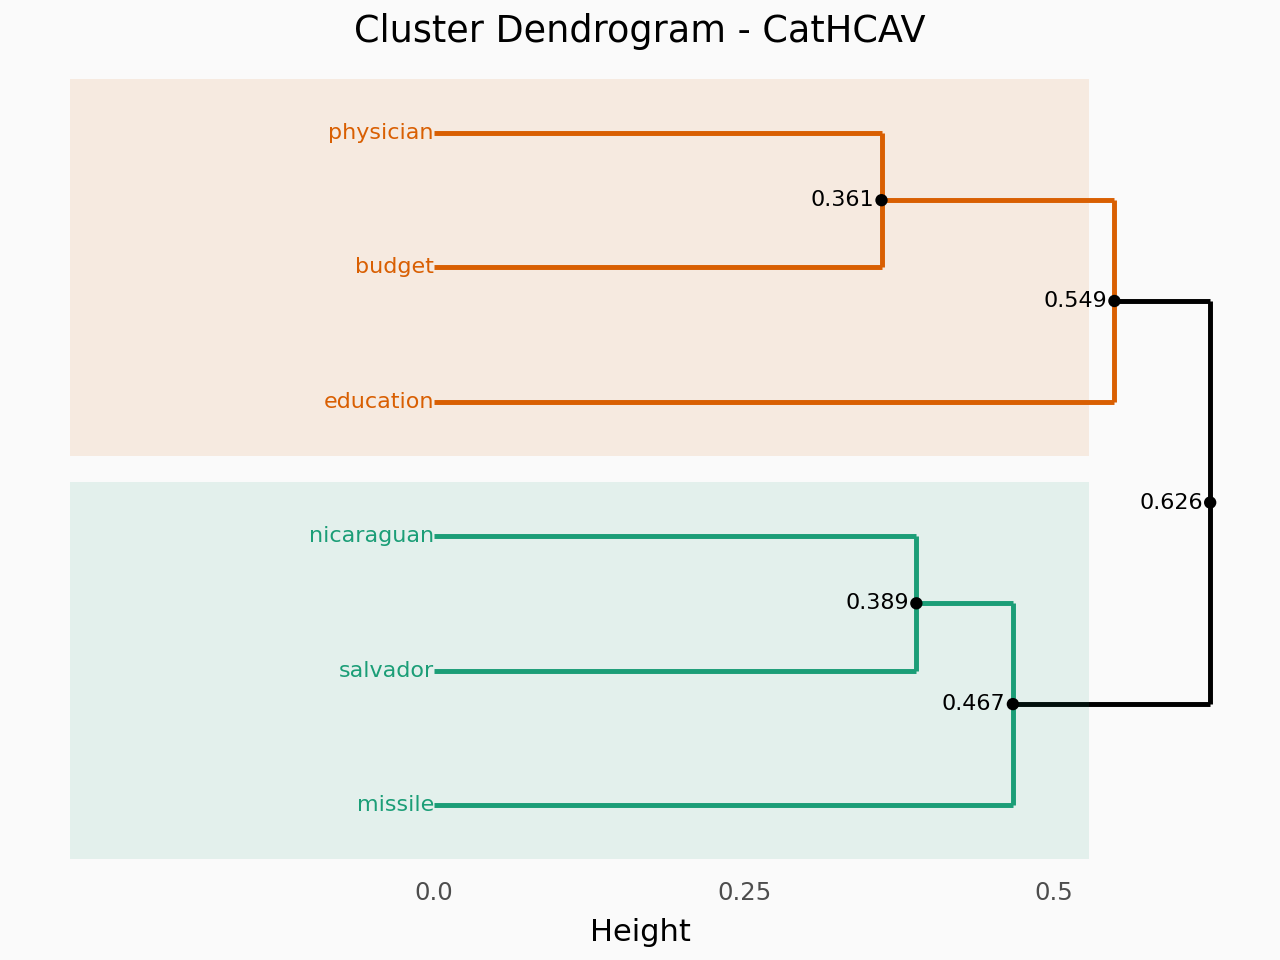

None


In [14]:
# horizon 
p = fviz_dend(obj=clf,
              horiz=True,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_x=-0.006)
print(p.show())

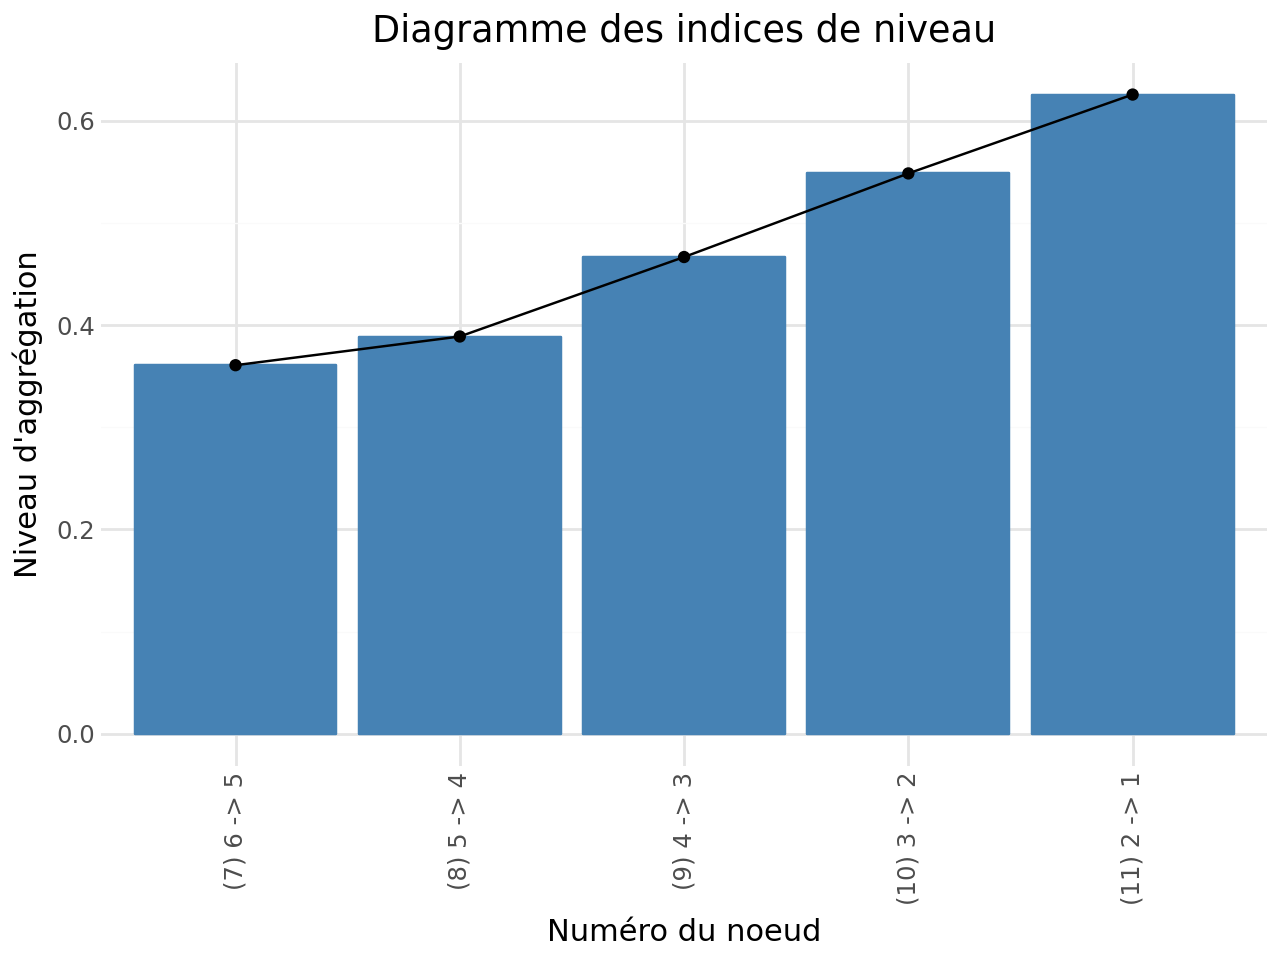

None


In [15]:
# graph of height
p = fviz_height(clf)
print(p.show())

## Supplementary variables informations

In [16]:
# supplementary variables informations
var_sup_ = clf.quali_var_sup_
var_sup_._fields

('cluster', 'dist', 'member')

### Cluster

In [17]:
# cluster
var_sup_.cluster.to_frame()

,cluster
affiliation,2


### Cluster distance

In [18]:
# distance - supplementary variables
var_sup_.dist

,1,2
affiliation,0.249775,0.164621


### Cluster member

In [19]:
# cluster member
var_sup_.member.sort_values(by=["Cluster","Variable"])

,Variable,Cluster,Own Cluster,Next Closest,Ratio (Own/Next)
0,affiliation,2,0.164621,0.249775,0.659078


## Summary

In [20]:
# summary
from clustvartools import summary
summary(clf)

                     Clustering of Variables - CatHCAV Results                     

Cluster Distance:
                 1       2
budget      0.3843  0.2214
physician   0.3586  0.2130
salvador    0.2078  0.3618
nicaraguan  0.2109  0.3740
missile     0.2242  0.4159
education   0.4087  0.2539

Cluster Members and Distance values:
     Variable Cluster Own Cluster Next Closest Ratio (Own/Next)
0      budget       2    0.221354     0.384252         0.576064
1   physician       2    0.212976     0.358645         0.593836
2    salvador       1    0.207755     0.361768         0.574277
3  nicaraguan       1    0.210917     0.374001         0.563948
4     missile       1    0.224231     0.415852         0.539209
5   education       2    0.253939     0.408724         0.621297

Cluster Distance - Supplementary variables:
                  1       2
affiliation  0.2498  0.1646

Cluster Members and Distance values - Supplementary variables:
      Variable Cluster Own Cluster Next Closest Ratio (Ow

In [21]:
# markdown formatting
summary(clf,to_markdown=True)

                     Clustering of Variables - CatHCAV Results                     

Cluster Distance:
                 1       2
----------  ------  ------
budget      0.3843  0.2214
physician   0.3586  0.213
salvador    0.2078  0.3618
nicaraguan  0.2109  0.374
missile     0.2242  0.4159
education   0.4087  0.2539

Cluster Members and Distance values:
    Variable      Cluster    Own Cluster    Next Closest    Ratio (Own/Next)
--  ----------  ---------  -------------  --------------  ------------------
 0  budget              2       0.221354        0.384252            0.576064
 1  physician           2       0.212976        0.358645            0.593836
 2  salvador            1       0.207755        0.361768            0.574277
 3  nicaraguan          1       0.210917        0.374001            0.563948
 4  missile             1       0.224231        0.415852            0.539209
 5  education           2       0.253939        0.408724            0.621297

Cluster Distance - Supplemen